[cache] loaded /workspaces/finance-data-download-test/notebooks/outputs/experiment_bsc/cache/partA_results_9e0ceacefb82.csv
[cache] loaded /workspaces/finance-data-download-test/notebooks/outputs/experiment_bsc/cache/partA_diagnostics_9e0ceacefb82.csv


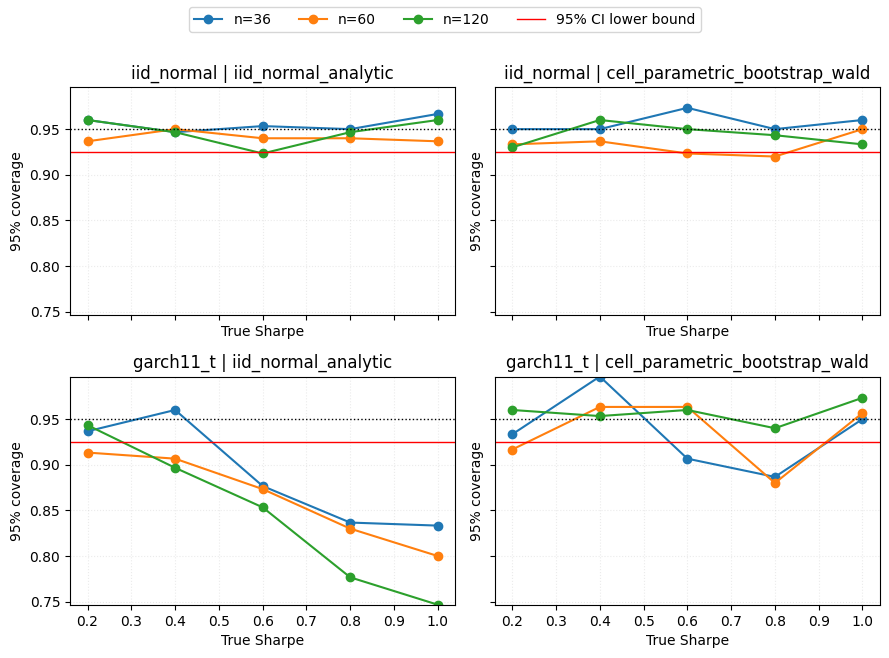

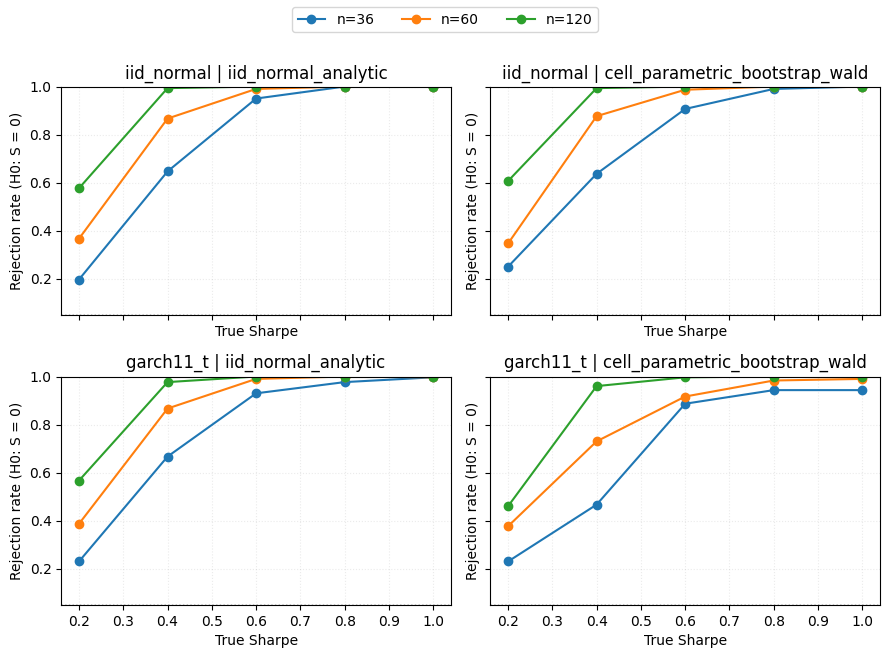

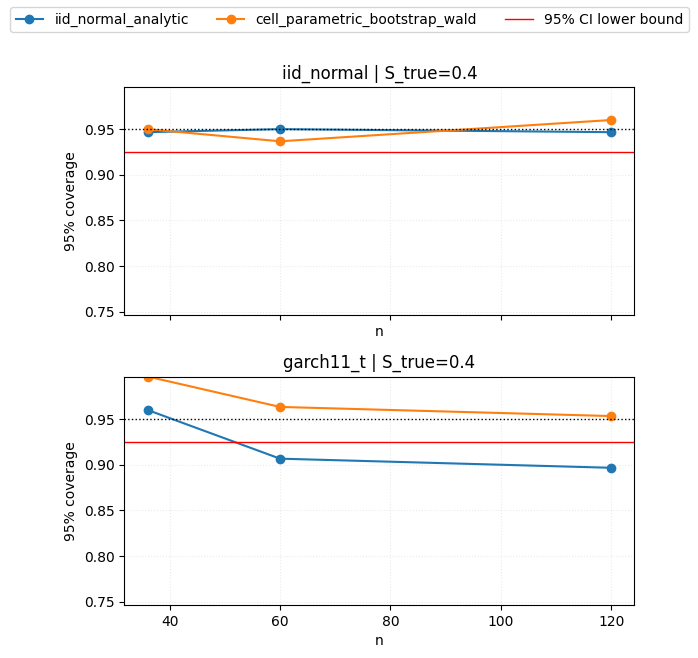

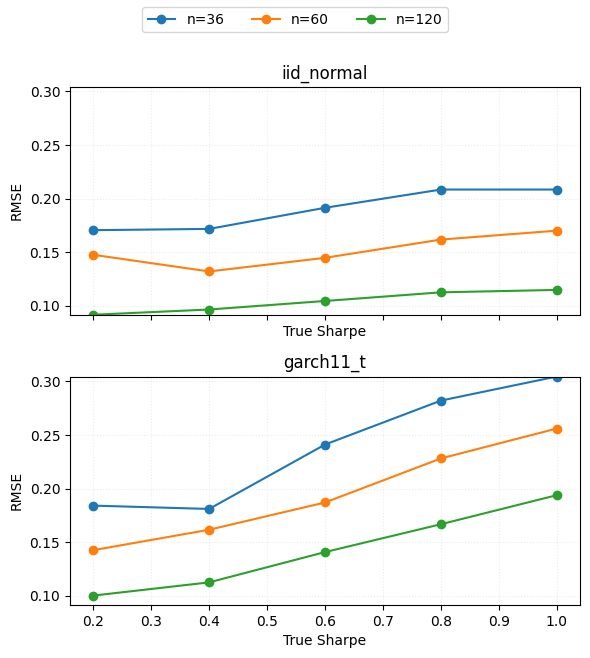

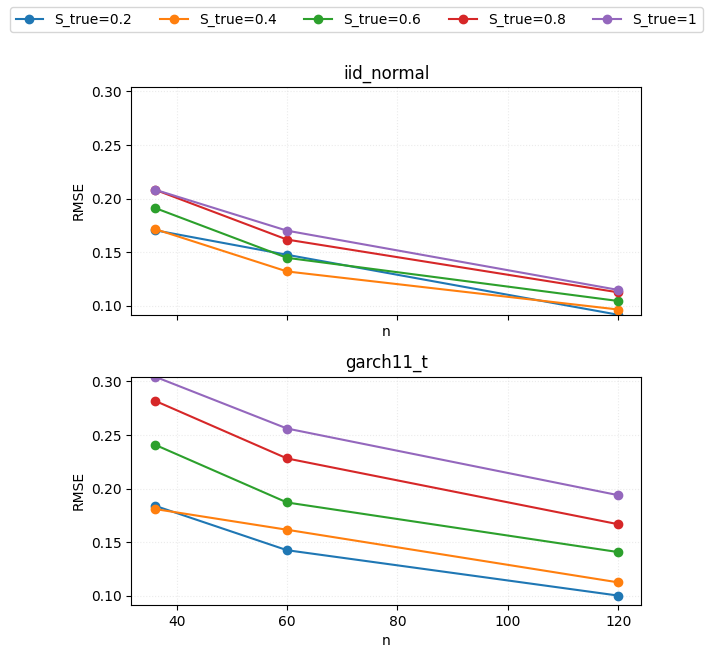

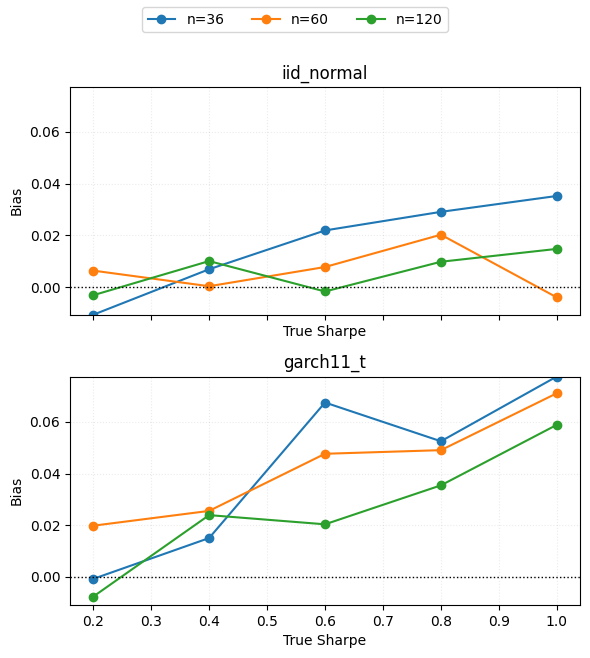

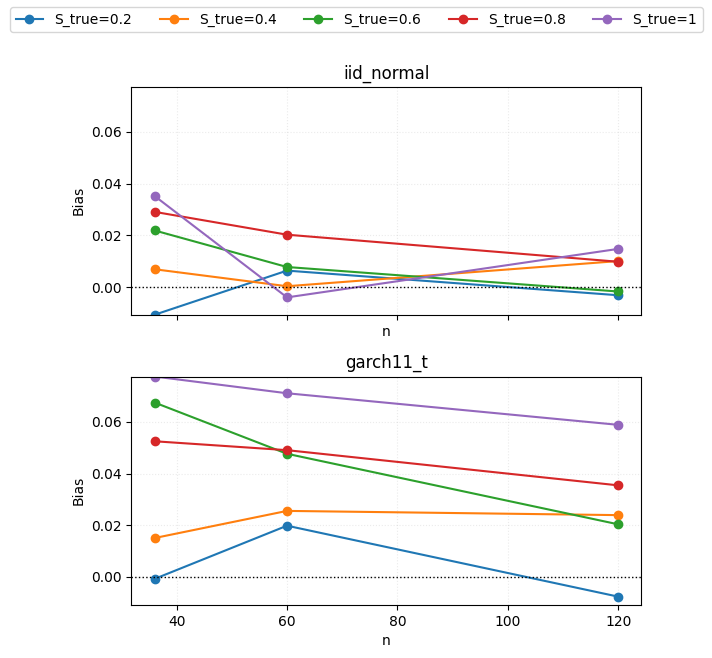

           dgp    n  S_true                          method  coverage_95  \
0    garch11_t   36     0.2  cell_parametric_bootstrap_wald     0.933333   
1    garch11_t   36     0.2             iid_normal_analytic     0.936667   
2    garch11_t   36     0.4  cell_parametric_bootstrap_wald     0.996667   
3    garch11_t   36     0.4             iid_normal_analytic     0.960000   
4    garch11_t   36     0.6  cell_parametric_bootstrap_wald     0.906667   
5    garch11_t   36     0.6             iid_normal_analytic     0.876667   
6    garch11_t   36     0.8  cell_parametric_bootstrap_wald     0.886667   
7    garch11_t   36     0.8             iid_normal_analytic     0.836667   
8    garch11_t   36     1.0  cell_parametric_bootstrap_wald     0.950000   
9    garch11_t   36     1.0             iid_normal_analytic     0.833333   
10   garch11_t   60     0.2  cell_parametric_bootstrap_wald     0.916667   
11   garch11_t   60     0.2             iid_normal_analytic     0.913333   
12   garch11

In [1]:
#!/usr/bin/env python3
from __future__ import annotations

import hashlib
import json
import os
import platform
import sys
from concurrent.futures import ProcessPoolExecutor, as_completed
from dataclasses import asdict, dataclass
from pathlib import Path
from statistics import NormalDist

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================
# Core stats
# ============================================================
def sharpe_hat(x: np.ndarray) -> float:
    x = np.asarray(x, float)
    s = x.std(ddof=1)
    return np.nan if (not np.isfinite(s) or s <= 0) else x.mean() / s


def wald_ci(S_hat: float, se: float, alpha: float) -> tuple[float, float]:
    z = NormalDist().inv_cdf(1.0 - alpha / 2.0)
    return (S_hat - z * se, S_hat + z * se)


# ============================================================
# DGPs (TRUE world)
# ============================================================
def simulate_iid_normal(
    rng: np.random.Generator, n: int, S_true: float, sigma: float = 1.0
) -> np.ndarray:
    mu = S_true * sigma
    return mu + sigma * rng.standard_normal(n)


def simulate_garch11_t(
    rng: np.random.Generator,
    n: int,
    S_true: float,
    g_alpha: float,
    g_beta: float,
    nu: float,
    sigma_uncond: float = 1.0,
    burn: int = 500,
) -> np.ndarray:
    if g_alpha + g_beta >= 1:
        raise ValueError("Need g_alpha + g_beta < 1 for finite unconditional variance.")
    if nu <= 2:
        raise ValueError("Need nu > 2 to standardize t innovations to Var=1.")

    omega = (1.0 - g_alpha - g_beta) * (sigma_uncond**2)
    mu = S_true * sigma_uncond

    m = burn + n
    h = np.empty(m, float)
    eps = np.empty(m, float)
    x = np.empty(m, float)

    # Standardize t innovations to Var(z)=1
    z = rng.standard_t(df=nu, size=m) * np.sqrt((nu - 2.0) / nu)

    h[0] = sigma_uncond**2
    eps[0] = np.sqrt(h[0]) * z[0]
    x[0] = mu + eps[0]

    for t in range(1, m):
        h[t] = omega + g_alpha * (eps[t - 1] ** 2) + g_beta * h[t - 1]
        eps[t] = np.sqrt(h[t]) * z[t]
        x[t] = mu + eps[t]

    return x[burn:]


def simulate_from_true_dgp(
    rng: np.random.Generator, dgp: str, n: int, S_true: float, cfg: "Config"
) -> np.ndarray:
    if dgp == "iid_normal":
        return simulate_iid_normal(rng, n=n, S_true=S_true, sigma=1.0)
    if dgp == "garch11_t":
        return simulate_garch11_t(
            rng,
            n=n,
            S_true=S_true,
            g_alpha=cfg.g_alpha,
            g_beta=cfg.g_beta,
            nu=cfg.nu,
            sigma_uncond=1.0,
            burn=cfg.burn,
        )
    raise ValueError(f"Unknown dgp: {dgp}")


# ============================================================
# "Fit once per cell" + Parametric bootstrap from fitted law
# (matches your paragraph)
# ============================================================
def fit_model_to_data(dgp: str, x: np.ndarray, cfg: "Config") -> dict:
    """
    Minimal parametric fit used ONLY to create a fitted law P_{theta_hat_cell}.

    - iid_normal: estimate (mu, sigma).
    - garch11_t: treat (g_alpha, g_beta, nu) as specified; estimate (mu, sigma_uncond).
      This is an MVP consistent with "specified innovation law" + fixed GARCH parameters.
    """
    x = np.asarray(x, float)
    mu_hat = float(np.nanmean(x))
    sigma_hat = float(np.nanstd(x, ddof=1))
    if not np.isfinite(sigma_hat) or sigma_hat <= 0:
        sigma_hat = np.nan

    if dgp == "iid_normal":
        return {"model": "iid_normal", "mu": mu_hat, "sigma": sigma_hat}

    if dgp == "garch11_t":
        return {
            "model": "garch11_t",
            "mu": mu_hat,
            "sigma_uncond": sigma_hat,
            "g_alpha": cfg.g_alpha,
            "g_beta": cfg.g_beta,
            "nu": cfg.nu,
            "burn": cfg.burn,
        }

    raise ValueError(f"Unknown model for fit: {dgp}")


def simulate_from_fitted_model(rng: np.random.Generator, theta_hat: dict, n: int) -> np.ndarray:
    model = theta_hat["model"]

    if model == "iid_normal":
        mu = float(theta_hat["mu"])
        sigma = float(theta_hat["sigma"])
        if not np.isfinite(sigma) or sigma <= 0:
            return np.full(n, np.nan)
        return mu + sigma * rng.standard_normal(n)

    if model == "garch11_t":
        mu = float(theta_hat["mu"])
        sigma_uncond = float(theta_hat["sigma_uncond"])
        if not np.isfinite(sigma_uncond) or sigma_uncond <= 0:
            return np.full(n, np.nan)

        # Use implied Sharpe from fitted mean/vol to set drift consistently
        S_impl = mu / sigma_uncond

        return simulate_garch11_t(
            rng,
            n=n,
            S_true=S_impl,
            g_alpha=float(theta_hat["g_alpha"]),
            g_beta=float(theta_hat["g_beta"]),
            nu=float(theta_hat["nu"]),
            sigma_uncond=sigma_uncond,
            burn=int(theta_hat["burn"]),
        )

    raise ValueError(f"Unknown fitted model: {model}")


def se_cell_parametric_bootstrap_precompute(
    dgp: str,
    n: int,
    S_true: float,
    cfg: "Config",
    rng: np.random.Generator,
) -> float:
    """
    Cell-level precompute (constant across replications), matching your text:

      1) X_ref ~ P_{theta0}
      2) fit -> theta_hat_cell
      3) for b=1..B_cell: X* ~ P_{theta_hat_cell}, compute S_hat*
      4) SE_cell = sd(S_hat*)
         (Omega_hat_cell = n * Var_hat(S_hat*))
    """
    # 1) reference sample from the TRUE DGP
    x_ref = simulate_from_true_dgp(rng, dgp=dgp, n=n, S_true=S_true, cfg=cfg)

    # 2) fit to get theta_hat_cell
    theta_hat = fit_model_to_data(dgp, x_ref, cfg)

    # 3) parametric bootstrap from fitted law
    B = max(2, int(cfg.B_cell))
    S_star = np.empty(B, float)
    for b in range(B):
        x_star = simulate_from_fitted_model(rng, theta_hat=theta_hat, n=n)
        S_star[b] = sharpe_hat(x_star)

    # 4) SE_cell = sd(S_hat*)
    return float(np.nanstd(S_star, ddof=1))


# ============================================================
# SE estimator (baseline)
# ============================================================
def se_iid_analytic(S_hat: float, n: int) -> float:
    # iid normal plug-in: Var(S_hat) ~ (1 + 0.5 S^2) / n
    return float(np.sqrt((1.0 + 0.5 * S_hat**2) / n))


# ============================================================
# Experiment config + deterministic seeding
# ============================================================
@dataclass(frozen=True)
class Config:
    seed: int = 0
    alpha: float = 0.05

    R: int = 300
    B_cell: int = 300  # bootstrap replications used ONCE per cell

    dgps: tuple[str, ...] = ("iid_normal", "garch11_t")
    methods: tuple[str, ...] = ("iid_normal_analytic", "cell_parametric_bootstrap_wald")

    n_grid: tuple[int, ...] = (36, 60, 120)
    S_grid: tuple[float, ...] = (0.2, 0.4, 0.6, 0.8, 1.0)

    # GARCH truth (and assumed/fixed in the fitted model for MVP)
    g_alpha: float = 0.05
    g_beta: float = 0.90
    nu: float = 7.0
    burn: int = 500

    # parallel
    max_workers: int = max(1, (os.cpu_count() or 2) - 1)


def stable_seed(*parts: object) -> int:
    s = "|".join(str(p) for p in parts)
    h = hashlib.sha256(s.encode("utf-8")).hexdigest()
    return int(h[:16], 16)  # 64-bit-ish


def coverage_ci_lower_approx(R: int, nominal: float, alpha: float = 0.05) -> float:
    z = NormalDist().inv_cdf(1.0 - alpha / 2.0)
    se = np.sqrt(nominal * (1.0 - nominal) / R)
    return float(nominal - z * se)


def running_inside_ipykernel() -> bool:
    try:
        from IPython import get_ipython
    except Exception:
        return False
    ip = get_ipython()
    return ip is not None and getattr(ip, "kernel", None) is not None


def effective_max_workers(cfg: "Config") -> int:
    if cfg.max_workers <= 1:
        return 1
    if running_inside_ipykernel():
        print(
            "[info] ipykernel detected; using max_workers=1 because notebook-local "
            "functions are not importable by spawned worker processes."
        )
        return 1
    return int(cfg.max_workers)


# ============================================================
# One (dgp, n, S_true) cell (runs inside a worker process)
# ============================================================
def run_cell(dgp: str, n: int, S_true: float, cfg_dict: dict) -> tuple[list[dict], dict]:
    cfg = Config(**cfg_dict)

    # separate RNG streams: one for precompute, one for replications
    rng_pre = np.random.default_rng(stable_seed(cfg.seed, "pre", dgp, n, S_true))
    rng_rep = np.random.default_rng(stable_seed(cfg.seed, "rep", dgp, n, S_true))

    # Precompute SE once per cell via parametric bootstrap plug-in
    se_cell = se_cell_parametric_bootstrap_precompute(
        dgp=dgp, n=n, S_true=S_true, cfg=cfg, rng=rng_pre
    )
    omega_hat_cell = float(n * (se_cell**2)) if np.isfinite(se_cell) else np.nan

    S_hats: list[float] = []

    se_A: list[float] = []
    cov_A: list[float] = []
    rej_A: list[float] = []

    se_B: list[float] = []
    cov_B: list[float] = []
    rej_B: list[float] = []

    for _ in range(cfg.R):
        x = simulate_from_true_dgp(rng_rep, dgp=dgp, n=n, S_true=S_true, cfg=cfg)
        S_hat = sharpe_hat(x)
        S_hats.append(S_hat)

        # Method A: iid analytic (baseline)
        se = se_iid_analytic(S_hat, n)
        lo, hi = wald_ci(S_hat, se, cfg.alpha)
        se_A.append(se)
        cov_A.append(float(lo <= S_true <= hi))
        rej_A.append(float((lo > 0.0) or (hi < 0.0)))

        # Method B: cell-level parametric bootstrap SE (constant)
        se = se_cell
        lo, hi = wald_ci(S_hat, se, cfg.alpha)
        se_B.append(se)
        cov_B.append(float(lo <= S_true <= hi))
        rej_B.append(float((lo > 0.0) or (hi < 0.0)))

    S_arr = np.asarray(S_hats, float)
    mc_sd = float(np.nanstd(S_arr, ddof=1))
    bias = float(np.nanmean(S_arr - S_true))
    rmse = float(np.sqrt(np.nanmean((S_arr - S_true) ** 2)))

    diagnostics_row = {
        "dgp": dgp,
        "n": int(n),
        "S_true": float(S_true),
        "bias": bias,
        "rmse": rmse,
        "mc_sd_S_hat": mc_sd,
    }

    def pack(method: str, se_list, cov_list, rej_list) -> dict:
        se_arr = np.asarray(se_list, float)
        cov_arr = np.asarray(cov_list, float)
        rej_arr = np.asarray(rej_list, float)
        return {
            "dgp": dgp,
            "n": int(n),
            "S_true": float(S_true),
            "method": method,
            "coverage_95": float(np.nanmean(cov_arr)),
            "reject_rate_H0_S_eq_0": float(np.nanmean(rej_arr)),
            "se_ratio_meanSE_over_mcSD": float(np.nanmean(se_arr) / mc_sd) if mc_sd > 0 else np.nan,
            "fit_fail_rate": float(np.mean(np.isnan(se_arr))),
            "se_cell": float(se_cell) if method == "cell_parametric_bootstrap_wald" else np.nan,
            "omega_hat_cell": float(omega_hat_cell) if method == "cell_parametric_bootstrap_wald" else np.nan,
        }

    method_rows = [
        pack("iid_normal_analytic", se_A, cov_A, rej_A),
        pack("cell_parametric_bootstrap_wald", se_B, cov_B, rej_B),
    ]
    return method_rows, diagnostics_row

# ============================================================
# Run + cache
# ============================================================
def run_partA(cfg: Config) -> tuple[pd.DataFrame, pd.DataFrame]:
    tasks = [(dgp, n, s) for dgp in cfg.dgps for n in cfg.n_grid for s in cfg.S_grid]
    cfg_dict = asdict(cfg)
    workers = effective_max_workers(cfg)

    method_rows: list[dict] = []
    diagnostics_rows: list[dict] = []
    if workers <= 1:
        for (dgp, n, s) in tasks:
            rows_m, row_d = run_cell(dgp, n, s, cfg_dict)
            method_rows.extend(rows_m)
            diagnostics_rows.append(row_d)
    else:
        with ProcessPoolExecutor(max_workers=workers) as ex:
            futs = [ex.submit(run_cell, dgp, n, s, cfg_dict) for (dgp, n, s) in tasks]
            for fut in as_completed(futs):
                rows_m, row_d = fut.result()
                method_rows.extend(rows_m)
                diagnostics_rows.append(row_d)

    df_methods = pd.DataFrame(method_rows).sort_values(["dgp", "n", "S_true", "method"]).reset_index(drop=True)
    df_diagnostics = pd.DataFrame(diagnostics_rows).sort_values(["dgp", "n", "S_true"]).reset_index(drop=True)
    return df_methods, df_diagnostics

# ============================================================
# Plots
# ============================================================
def save_fig(fig: plt.Figure, fig_dir: Path, stem: str) -> None:
    fig_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(fig_dir / f"{stem}.png", dpi=160, bbox_inches="tight")
    fig.savefig(fig_dir / f"{stem}.pdf", bbox_inches="tight")


def plot_all(results: pd.DataFrame, diagnostics: pd.DataFrame, cfg: Config, fig_dir: Path) -> None:
    coverage_metric = "coverage_95"
    coverage_nominal = 0.95
    coverage_ci_lower = coverage_ci_lower_approx(cfg.R, coverage_nominal, alpha=0.05)

    coverage_min = min(float(results[coverage_metric].min()), coverage_ci_lower)
    coverage_max = max(float(results[coverage_metric].max()), coverage_nominal)
    if np.isclose(coverage_min, coverage_max):
        coverage_min -= 0.01
        coverage_max += 0.01

    n_values = sorted(int(v) for v in diagnostics["n"].unique())
    s_values = sorted(float(v) for v in diagnostics["S_true"].unique())

    # --- Coverage by S_true (lines are n), panel is dgp x method
    fig, axes = plt.subplots(
        len(cfg.dgps),
        len(cfg.methods),
        figsize=(4.5 * len(cfg.methods), 3.3 * len(cfg.dgps)),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    for i, dgp in enumerate(cfg.dgps):
        for j, method in enumerate(cfg.methods):
            ax = axes[i, j]
            subset = results[(results["dgp"] == dgp) & (results["method"] == method)]
            for n in n_values:
                n_rows = subset[subset["n"] == int(n)].sort_values("S_true")
                n_rows = n_rows.dropna(subset=[coverage_metric])
                if n_rows.empty:
                    continue
                ax.plot(n_rows["S_true"], n_rows[coverage_metric], marker="o", label=f"n={n}")
            ax.axhline(coverage_nominal, linestyle=":", color="black", linewidth=1.0)
            ax.axhline(
                coverage_ci_lower,
                linestyle="-",
                color="red",
                linewidth=1.0,
                label="95% CI lower bound" if (i == 0 and j == 0) else None,
            )
            ax.grid(alpha=0.25, linestyle=":")
            ax.set_title(f"{dgp} | {method}")
            ax.set_xlabel("True Sharpe")
            ax.set_ylabel("95% coverage")
            ax.set_ylim(coverage_min, coverage_max)

    handles, labels = [], []
    for ax in axes.ravel():
        h, l = ax.get_legend_handles_labels()
        if h:
            handles, labels = h, l
            break
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=min(len(labels), 6))
    fig.tight_layout(rect=(0, 0, 1, 0.93 if handles else 1.0))
    save_fig(fig, fig_dir, "partA_coverage_95_by_n_grid")
    plt.show()
    plt.close(fig)

    # --- Reject rate by S_true (two-sided H0: S = 0), panel is dgp x method
    reject_metric = "reject_rate_H0_S_eq_0"
    reject_nominal = cfg.alpha

    reject_min = min(float(results[reject_metric].min()), reject_nominal)
    reject_max = max(float(results[reject_metric].max()), reject_nominal)
    if np.isclose(reject_min, reject_max):
        reject_min -= 0.01
        reject_max += 0.01

    fig_r, axes_r = plt.subplots(
        len(cfg.dgps),
        len(cfg.methods),
        figsize=(4.5 * len(cfg.methods), 3.3 * len(cfg.dgps)),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    for i, dgp in enumerate(cfg.dgps):
        for j, method in enumerate(cfg.methods):
            ax = axes_r[i, j]
            subset = results[(results["dgp"] == dgp) & (results["method"] == method)]
            for n in n_values:
                n_rows = subset[subset["n"] == int(n)].sort_values("S_true")
                n_rows = n_rows.dropna(subset=[reject_metric])
                if n_rows.empty:
                    continue
                ax.plot(n_rows["S_true"], n_rows[reject_metric], marker="o", label=f"n={n}")
            ax.axhline(reject_nominal, linestyle=":", color="black", linewidth=1.0)
            ax.grid(alpha=0.25, linestyle=":")
            ax.set_title(f"{dgp} | {method}")
            ax.set_xlabel("True Sharpe")
            ax.set_ylabel("Rejection rate (H0: S = 0)")
            ax.set_ylim(reject_min, reject_max)

    handles_r, labels_r = [], []
    for ax in axes_r.ravel():
        h, l = ax.get_legend_handles_labels()
        if h:
            handles_r, labels_r = h, l
            break
    if handles_r:
        fig_r.legend(handles_r, labels_r, loc="upper center", ncol=min(len(labels_r), 6))
    fig_r.tight_layout(rect=(0, 0, 1, 0.93 if handles_r else 1.0))
    save_fig(fig_r, fig_dir, "partA_reject_rate_H0_S_eq_0_by_n_grid")
    plt.show()
    plt.close(fig_r)

    # --- Coverage vs n at fixed S_true (one column, dgp rows)
    target_s_true = 0.5
    if s_values and not any(np.isclose(v, target_s_true) for v in s_values):
        target_s_true = min(s_values, key=lambda v: abs(v - target_s_true))

    fig2, axes2 = plt.subplots(
        len(cfg.dgps),
        1,
        figsize=(6.0, 3.3 * len(cfg.dgps)),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    for i, dgp in enumerate(cfg.dgps):
        ax = axes2[i, 0]
        subset = results[(results["dgp"] == dgp) & (np.isclose(results["S_true"], float(target_s_true)))]
        for method in cfg.methods:
            m_rows = subset[subset["method"] == method].sort_values("n")
            m_rows = m_rows.dropna(subset=[coverage_metric])
            if m_rows.empty:
                continue
            ax.plot(m_rows["n"], m_rows[coverage_metric], marker="o", label=method)
        ax.axhline(coverage_nominal, linestyle=":", color="black", linewidth=1.0)
        ax.axhline(
            coverage_ci_lower,
            linestyle="-",
            color="red",
            linewidth=1.0,
            label="95% CI lower bound" if i == 0 else None,
        )
        ax.grid(alpha=0.25, linestyle=":")
        ax.set_title(f"{dgp} | S_true={target_s_true:g}")
        ax.set_xlabel("n")
        ax.set_ylabel("95% coverage")
        ax.set_ylim(coverage_min, coverage_max)

    handles2, labels2 = [], []
    for ax in axes2.ravel():
        h, l = ax.get_legend_handles_labels()
        if h:
            handles2, labels2 = h, l
            break
    if handles2:
        fig2.legend(handles2, labels2, loc="upper center", ncol=min(len(labels2), 6))
    fig2.tight_layout(rect=(0, 0, 1, 0.93 if handles2 else 1.0))
    save_fig(fig2, fig_dir, f"partA_coverage_95_vs_n_s_true_{str(target_s_true).replace('.', 'p')}")
    plt.show()
    plt.close(fig2)

    # --- RMSE and Bias plots (by DGP only)
    for metric_col, metric_label in [("rmse", "RMSE"), ("bias", "Bias")]:
        metric_min = float(diagnostics[metric_col].min())
        metric_max = float(diagnostics[metric_col].max())
        if metric_col == "bias":
            metric_min = min(metric_min, 0.0)
            metric_max = max(metric_max, 0.0)
        if np.isclose(metric_min, metric_max):
            pad = 0.01 if np.isclose(metric_max, 0.0) else abs(metric_max) * 0.05
            metric_min -= pad
            metric_max += pad

        # metric vs S_true (lines are n), panel is dgp
        fig_s, axes_s = plt.subplots(
            len(cfg.dgps),
            1,
            figsize=(6.0, 3.3 * len(cfg.dgps)),
            sharex=True,
            sharey=True,
            squeeze=False,
        )
        for i, dgp in enumerate(cfg.dgps):
            ax = axes_s[i, 0]
            subset = diagnostics[diagnostics["dgp"] == dgp]
            for n in n_values:
                n_rows = subset[subset["n"] == int(n)].sort_values("S_true")
                n_rows = n_rows.dropna(subset=[metric_col])
                if n_rows.empty:
                    continue
                ax.plot(n_rows["S_true"], n_rows[metric_col], marker="o", label=f"n={n}")
            if metric_col == "bias":
                ax.axhline(0.0, linestyle=":", color="black", linewidth=1.0)
            ax.grid(alpha=0.25, linestyle=":")
            ax.set_title(f"{dgp}")
            ax.set_xlabel("True Sharpe")
            ax.set_ylabel(metric_label)
            ax.set_ylim(metric_min, metric_max)

        handles_s, labels_s = [], []
        for ax in axes_s.ravel():
            h, l = ax.get_legend_handles_labels()
            if h:
                handles_s, labels_s = h, l
                break
        if handles_s:
            fig_s.legend(handles_s, labels_s, loc="upper center", ncol=min(len(labels_s), 6))
        fig_s.tight_layout(rect=(0, 0, 1, 0.93 if handles_s else 1.0))
        save_fig(fig_s, fig_dir, f"partA_{metric_col}_vs_s_true_by_n_grid")
        plt.show()
        plt.close(fig_s)

        # metric vs n (lines are S_true), panel is dgp
        fig_n, axes_n = plt.subplots(
            len(cfg.dgps),
            1,
            figsize=(6.0, 3.3 * len(cfg.dgps)),
            sharex=True,
            sharey=True,
            squeeze=False,
        )
        for i, dgp in enumerate(cfg.dgps):
            ax = axes_n[i, 0]
            subset = diagnostics[diagnostics["dgp"] == dgp]
            for s_true in s_values:
                s_rows = subset[np.isclose(subset["S_true"], float(s_true))].sort_values("n")
                s_rows = s_rows.dropna(subset=[metric_col])
                if s_rows.empty:
                    continue
                ax.plot(s_rows["n"], s_rows[metric_col], marker="o", label=f"S_true={s_true:g}")
            if metric_col == "bias":
                ax.axhline(0.0, linestyle=":", color="black", linewidth=1.0)
            ax.grid(alpha=0.25, linestyle=":")
            ax.set_title(f"{dgp}")
            ax.set_xlabel("n")
            ax.set_ylabel(metric_label)
            ax.set_ylim(metric_min, metric_max)

        handles_n, labels_n = [], []
        for ax in axes_n.ravel():
            h, l = ax.get_legend_handles_labels()
            if h:
                handles_n, labels_n = h, l
                break
        if handles_n:
            fig_n.legend(handles_n, labels_n, loc="upper center", ncol=min(len(labels_n), 6))
        fig_n.tight_layout(rect=(0, 0, 1, 0.93 if handles_n else 1.0))
        save_fig(fig_n, fig_dir, f"partA_{metric_col}_vs_n_by_s_true_grid")
        plt.show()
        plt.close(fig_n)

def try_write_parquet(df: pd.DataFrame, path: Path) -> None:
    try:
        df.to_parquet(path, index=False)
    except Exception:
        pass


def env_versions() -> dict:
    try:
        import importlib.metadata as ilmd
    except Exception:
        ilmd = None

    pkgs = ["numpy", "pandas", "matplotlib", "pyarrow"]
    versions = {}
    for p in pkgs:
        try:
            versions[p] = ilmd.version(p) if ilmd else None
        except Exception:
            versions[p] = None
    return {
        "python": sys.version,
        "platform": platform.platform(),
        "packages": versions,
    }


# ============================================================
# Main
# ============================================================
if __name__ == "__main__":
    try:
        import multiprocessing as mp

        if not running_inside_ipykernel():
            mp.set_start_method("spawn", force=False)
    except Exception:
        pass

    run_dir = Path(os.environ.get("EXPERIMENT_BSC_OUTPUT_DIR", "outputs/experiment_bsc")).resolve()
    cache_dir = run_dir / "cache"
    fig_dir = run_dir / "figures"
    for p in (run_dir, cache_dir, fig_dir):
        p.mkdir(parents=True, exist_ok=True)

    cfg = Config(
        seed=int(os.environ.get("SEED", "0")),
        R=int(os.environ.get("R", "300")),
        B_cell=int(os.environ.get("B_CELL", "300")),
        max_workers=int(os.environ.get("MAX_WORKERS", str(Config().max_workers))),
    )

    cfg_payload = json.dumps(asdict(cfg), sort_keys=True, separators=(",", ":"))
    cfg_hash = hashlib.sha256(cfg_payload.encode("utf-8")).hexdigest()[:12]
    cache_csv = cache_dir / f"partA_results_{cfg_hash}.csv"
    cache_parquet = cache_dir / f"partA_results_{cfg_hash}.parquet"
    cache_diag_csv = cache_dir / f"partA_diagnostics_{cfg_hash}.csv"
    cache_diag_parquet = cache_dir / f"partA_diagnostics_{cfg_hash}.parquet"

    if cache_csv.exists() and cache_diag_csv.exists():
        results = pd.read_csv(cache_csv)
        diagnostics = pd.read_csv(cache_diag_csv)
        print(f"[cache] loaded {cache_csv}")
        print(f"[cache] loaded {cache_diag_csv}")
    else:
        results, diagnostics = run_partA(cfg)
        results.to_csv(cache_csv, index=False)
        diagnostics.to_csv(cache_diag_csv, index=False)
        try_write_parquet(results, cache_parquet)
        try_write_parquet(diagnostics, cache_diag_parquet)
        (run_dir / f"config_partA_{cfg_hash}.json").write_text(json.dumps(asdict(cfg), indent=2), encoding="utf-8")
        (run_dir / f"env_versions_{cfg_hash}.json").write_text(json.dumps(env_versions(), indent=2), encoding="utf-8")
        print(f"[run] wrote {cache_csv}")
        print(f"[run] wrote {cache_diag_csv}")

    legacy_reject_cols = [
        c
        for c in results.columns
        if c.startswith("reject_rate_H0_") and c.endswith("_0") and c != "reject_rate_H0_S_eq_0"
    ]
    if legacy_reject_cols and "reject_rate_H0_S_eq_0" not in results.columns:
        results = results.rename(columns={legacy_reject_cols[0]: "reject_rate_H0_S_eq_0"})

    for col in ["bias", "rmse", "mc_sd_S_hat"]:
        if col in results.columns:
            results = results.drop(columns=[col])

    # “latest” copy
    results.to_csv(run_dir / "results_partA_cell_parametric_bootstrap.csv", index=False)
    diagnostics.to_csv(run_dir / "results_partA_diagnostics.csv", index=False)

    plot_all(results, diagnostics, cfg, fig_dir)

    print(results)
    print(diagnostics)
    print()
    print(f"Results: {run_dir / 'results_partA_cell_parametric_bootstrap.csv'}")
    print(f"Diagnostics: {run_dir / 'results_partA_diagnostics.csv'}")
    print(f"Figures: {fig_dir}")


In [2]:
from time import perf_counter

# Step 1: choose trial values
R0 = 500
B0 = 300

trial_cfg = Config(R=R0, B_cell=B0, max_workers=1)
trial_dgp = "garch11_t" if "garch11_t" in trial_cfg.dgps else trial_cfg.dgps[0]
trial_n = trial_cfg.n_grid[len(trial_cfg.n_grid) // 2]
trial_s_true = trial_cfg.S_grid[len(trial_cfg.S_grid) // 2]

# Step 2: time one representative cell
t0 = perf_counter()
trial_rows, trial_diag = run_cell(trial_dgp, trial_n, trial_s_true, asdict(trial_cfg))
elapsed_cell = perf_counter() - t0
t_rep_hat = elapsed_cell / R0

summary = pd.Series(
    {
        "R0": R0,
        "B0": B0,
        "representative_dgp": trial_dgp,
        "representative_n": trial_n,
        "representative_S_true": trial_s_true,
        "elapsed_cell_seconds": elapsed_cell,
        "t_rep_hat_seconds": t_rep_hat,
    },
    name="timing_trial",
)
summary


R0                             500
B0                             300
representative_dgp       garch11_t
representative_n                60
representative_S_true          0.6
elapsed_cell_seconds      0.819182
t_rep_hat_seconds         0.001638
Name: timing_trial, dtype: object